In [2]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [4]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

In [5]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-2.000 – 2.000 sec
Baseline,off


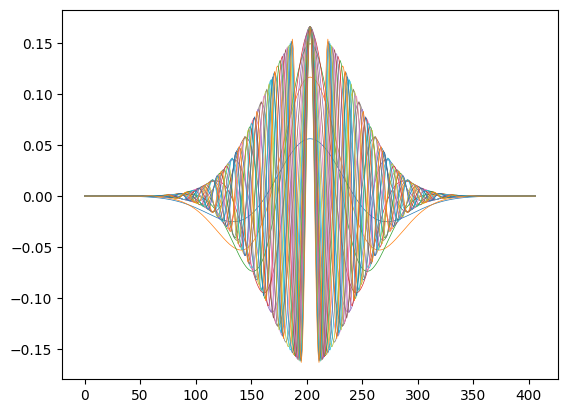

In [6]:
fmax = 16
sfreq=fmax*2
n_freqs=int(sfreq*0.7)
freqs = np.linspace(0.5, fmax, n_freqs)
n_cycles = freqs
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)
plt.show()

In [26]:
epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='power', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.data = np.abs(epochs_tfr.data)
epochs_tfr.crop(-0.5, 1)
epochs_tfr.apply_baseline((-0.5, -0.1), 'logratio')
epochs_tfr.apply_baseline((-0.5, -0.1), 'mean')
epochs_tfr.crop(0, 0.8)


epochs_tfr

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   18.5s remaining:   30.9s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   24.8s remaining:   14.9s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   26.1s finished


Not setting metadata
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: mean)


<EpochsTFR | time : [0.000000, 0.812500], freq : [0.500000, 16.000000], epochs : 4200, channels : 8, ~152.3 MB>

In [27]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [28]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [29]:
import tensorly.decomposition
import tensorly.tenalg
X_train = epochs_train.data
y_train = labels_train
X_test = epochs_test.data
y_test = labels_test

X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:,:]


In [30]:
import tensorly as tl
tl.set_backend('cupy')


In [50]:
hoda = HODA(max_iter=128, rank=None, tol=1e-6, initialize ='ones', verbose=True, 
            shrinkage=('oas','oas','oas'), toeplitz=None, solver='ratio-svd')
hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0019  shrinkage=0.0091  shrinkage=0.0017  step=1.2061e+01
[1/128]  shrinkage=0.0480  shrinkage=0.1470  shrinkage=0.0020  step=3.7754e+00
[2/128]  shrinkage=0.0027  shrinkage=0.0148  shrinkage=0.0019  step=3.7591e+00
[3/128]  shrinkage=0.0036  shrinkage=0.0222  shrinkage=0.0022  step=3.8830e+00
[4/128]  shrinkage=0.0026  shrinkage=0.0135  shrinkage=0.0020  step=3.6998e+00
[5/128]  shrinkage=0.0036  shrinkage=0.0191  shrinkage=0.0022  step=3.4462e+00
[6/128]  shrinkage=0.0027  shrinkage=0.0139  shrinkage=0.0020  step=3.6503e+00
[7/128]  shrinkage=0.0032  shrinkage=0.0168  shrinkage=0.0022  step=3.5941e+00
[8/128]  shrinkage=0.0028  shrinkage=0.0143  shrinkage=0.0020  step=3.5515e+00
[9/128]  shrinkage=0.0031  shrinkage=0.0155  shrinkage=0.0022  step=3.4541e+00
[10/128]  shrinkage=0.0028  shrinkage=0.0145  shrinkage=0.0021  step=3.7206e+00
[11/128]  shrinkage=0.0031  shrinkage=0.0148  shrinkage=0.0022  step=3.7488e+00
[12/128]  shrinkage=0.0029  shrinkage=0.0147  shri

[104/128]  shrinkage=0.0032  shrinkage=0.0189  shrinkage=0.0023  step=3.6426e+00
[105/128]  shrinkage=0.0026  shrinkage=0.0145  shrinkage=0.0021  step=3.6295e+00
[106/128]  shrinkage=0.0031  shrinkage=0.0179  shrinkage=0.0023  step=3.4930e+00
[107/128]  shrinkage=0.0027  shrinkage=0.0146  shrinkage=0.0021  step=3.4425e+00
[108/128]  shrinkage=0.0030  shrinkage=0.0173  shrinkage=0.0022  step=3.2146e+00
[109/128]  shrinkage=0.0027  shrinkage=0.0147  shrinkage=0.0021  step=3.3200e+00
[110/128]  shrinkage=0.0031  shrinkage=0.0174  shrinkage=0.0022  step=3.2898e+00
[111/128]  shrinkage=0.0027  shrinkage=0.0147  shrinkage=0.0021  step=3.2284e+00
[112/128]  shrinkage=0.0031  shrinkage=0.0176  shrinkage=0.0022  step=3.1622e+00
[113/128]  shrinkage=0.0027  shrinkage=0.0147  shrinkage=0.0021  step=3.0546e+00
[114/128]  shrinkage=0.0031  shrinkage=0.0177  shrinkage=0.0022  step=3.0638e+00
[115/128]  shrinkage=0.0027  shrinkage=0.0146  shrinkage=0.0021  step=3.0668e+00
[116/128]  shrinkage=0.0031 

HODA(max_iter=128, shrinkage=('oas', 'oas', 'oas'), solver='ratio-svd',
     tol=1e-06, verbose=True)

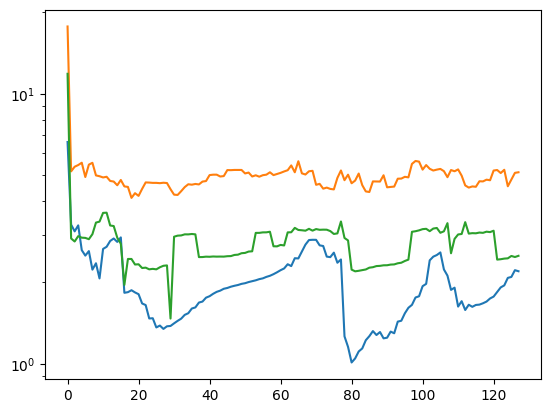

In [51]:
import cupy
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

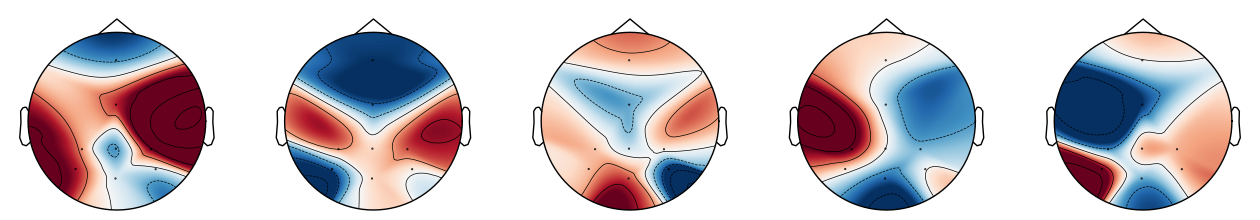

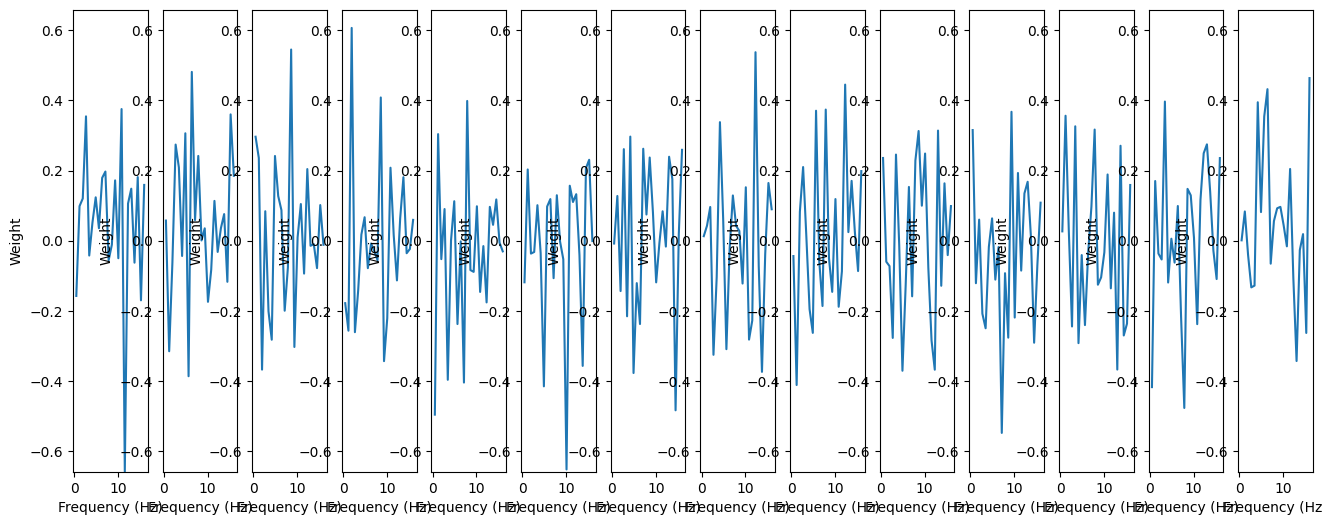

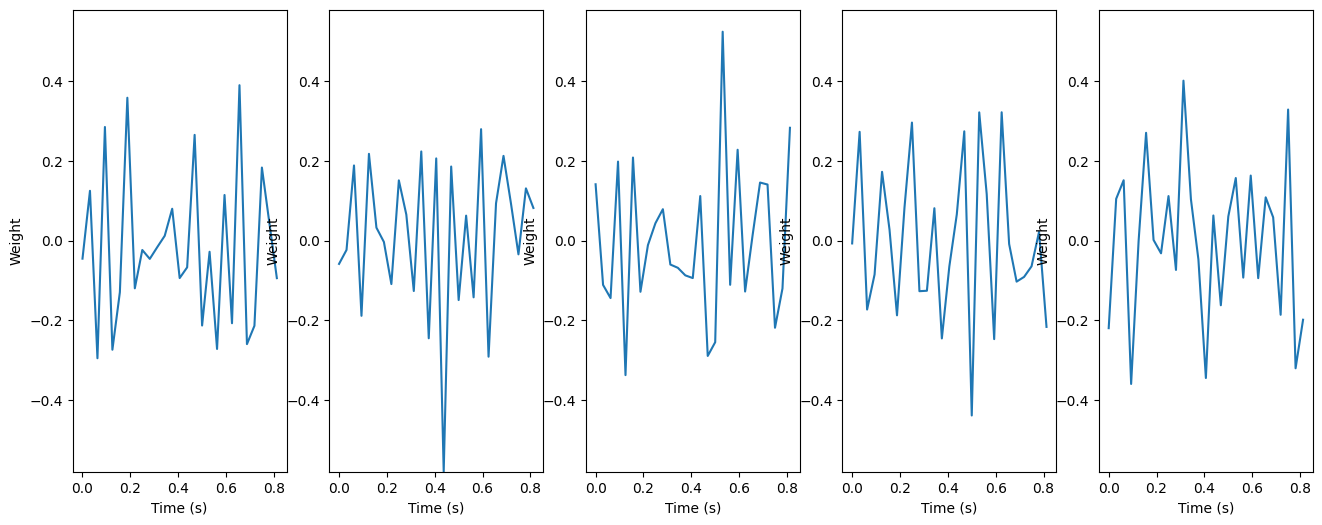

In [52]:
projs = [cupy.asnumpy(p) for k, p in enumerate(hoda.projs_)]


fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(projs[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = projs[1][:,i]
    axs[i].plot(freqs, w)
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(projs[2]))
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6))
for i in range(hoda.rank_[2]):
    w = projs[2][:,i]
    axs[i].plot(epochs_tfr.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])
plt.show()

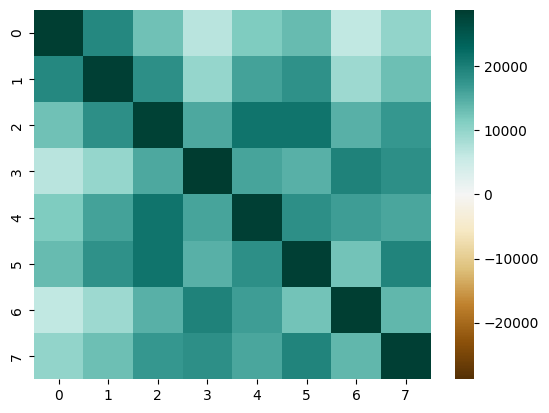

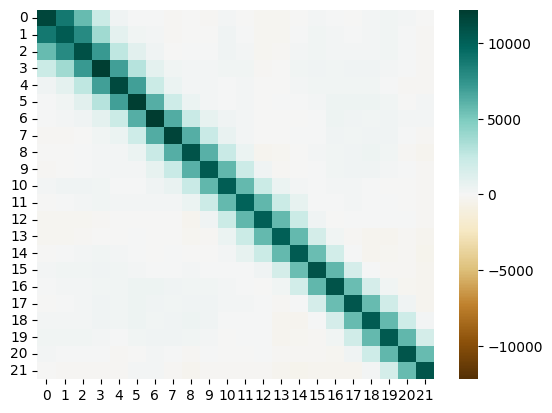

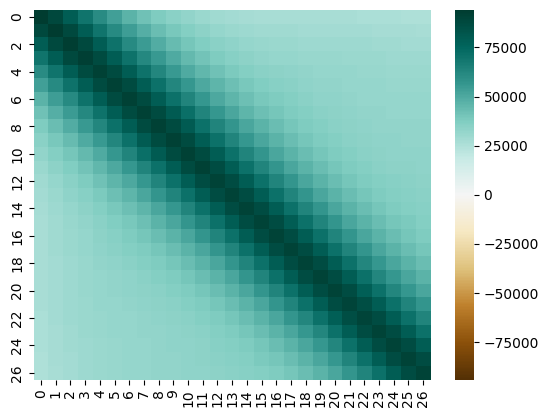

In [53]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

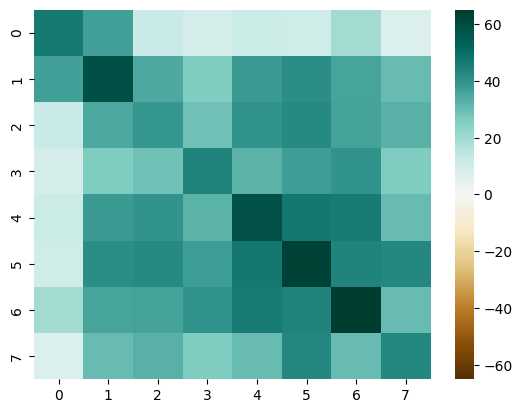

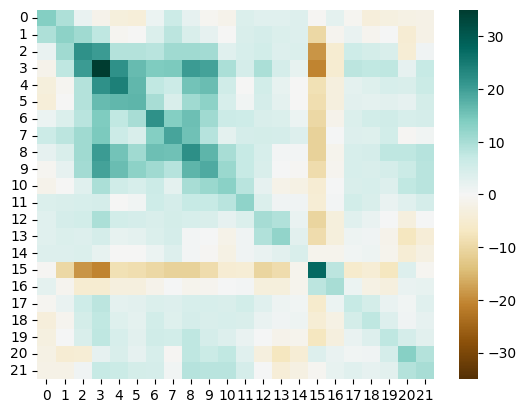

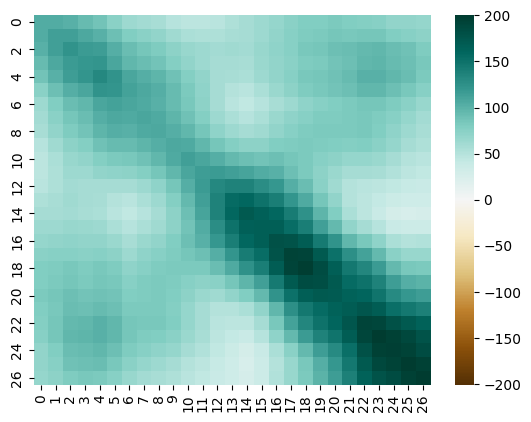

In [54]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

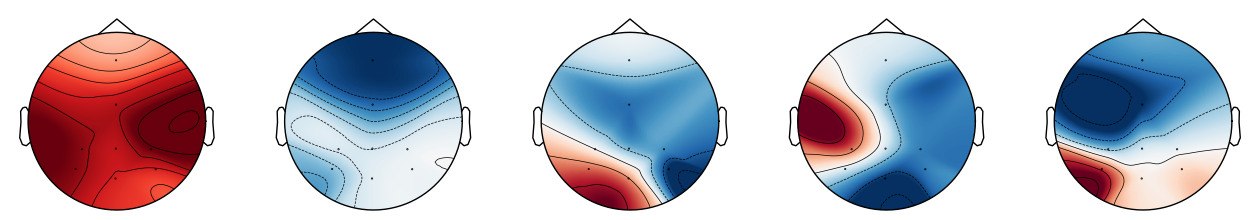

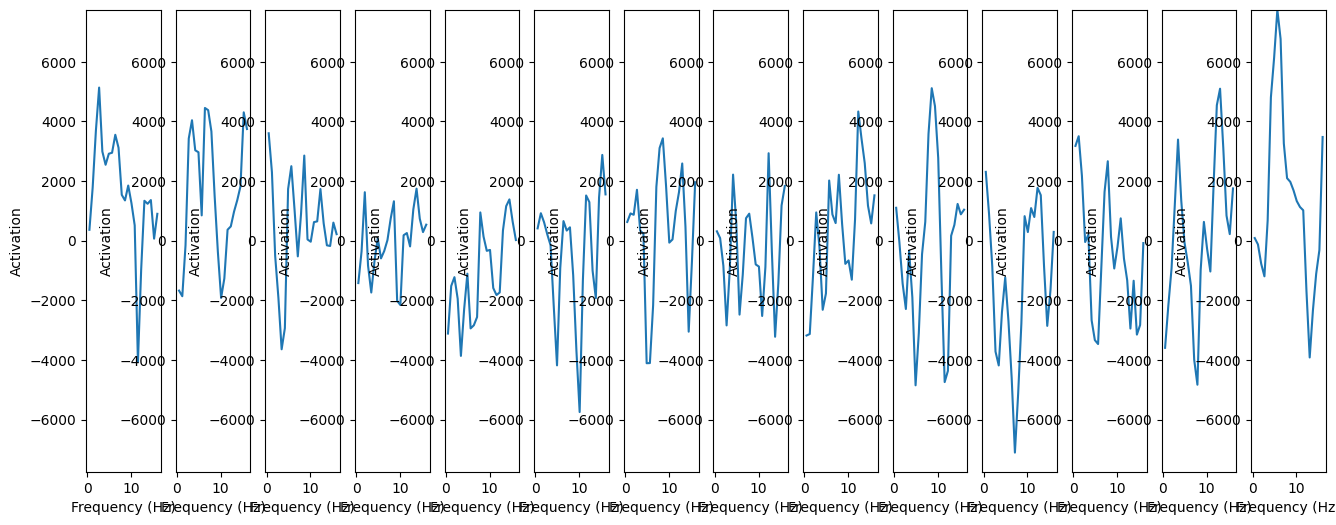

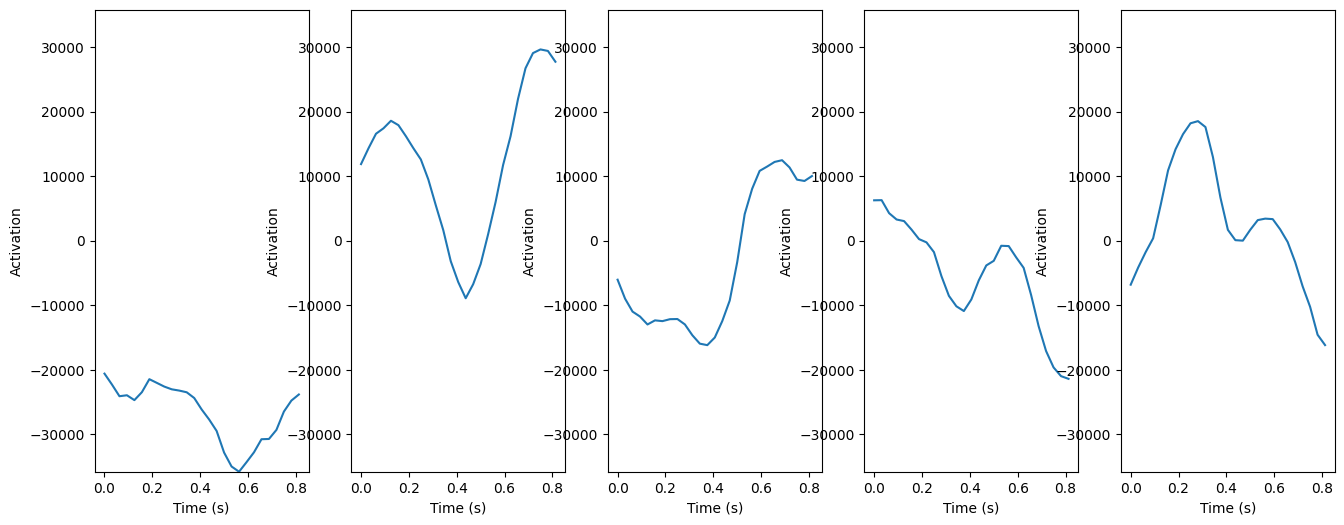

In [56]:
aps = [cupy.asnumpy(hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]


fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank_[1]):
    w = aps[1][:,i]
    axs[i].plot(freqs, w)
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Activation')
    axs[i].set_ylim([-vmax, vmax])

fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6))
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank_[2]):
    w = aps[2][:,i]
    axs[i].plot(epochs_tfr.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Activation')
    axs[i].set_ylim([-vmax, vmax])
plt.show()

In [57]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)

"""
fu = FeatureUnion([("real",FunctionTransformer(np.real)),
                   ("imag",FunctionTransformer(np.imag))])

Xt_train = fu.fit_transform(Xt_train)
Xt_test = fu.transform(Xt_test)
"""
Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

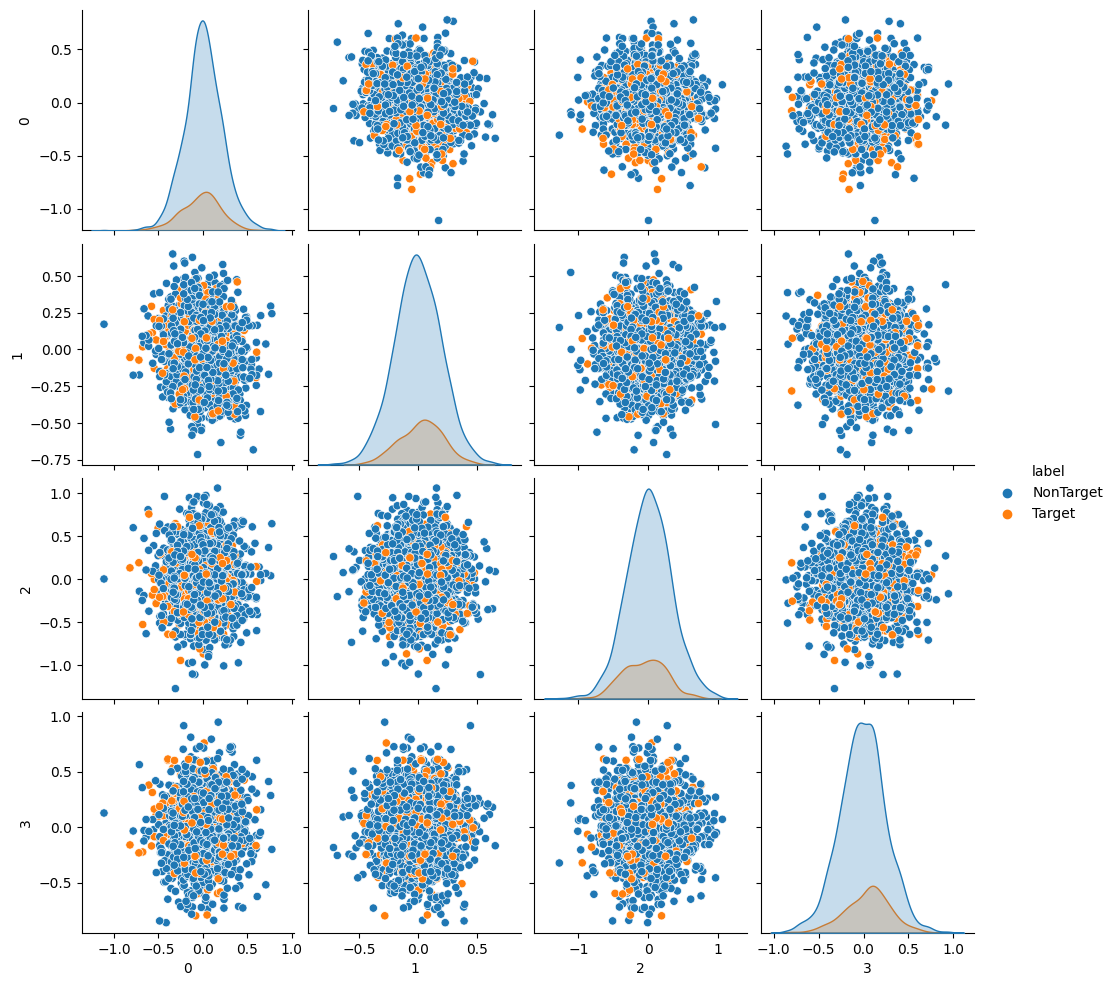

In [59]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')
plt.show()

In [60]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8672228571428572

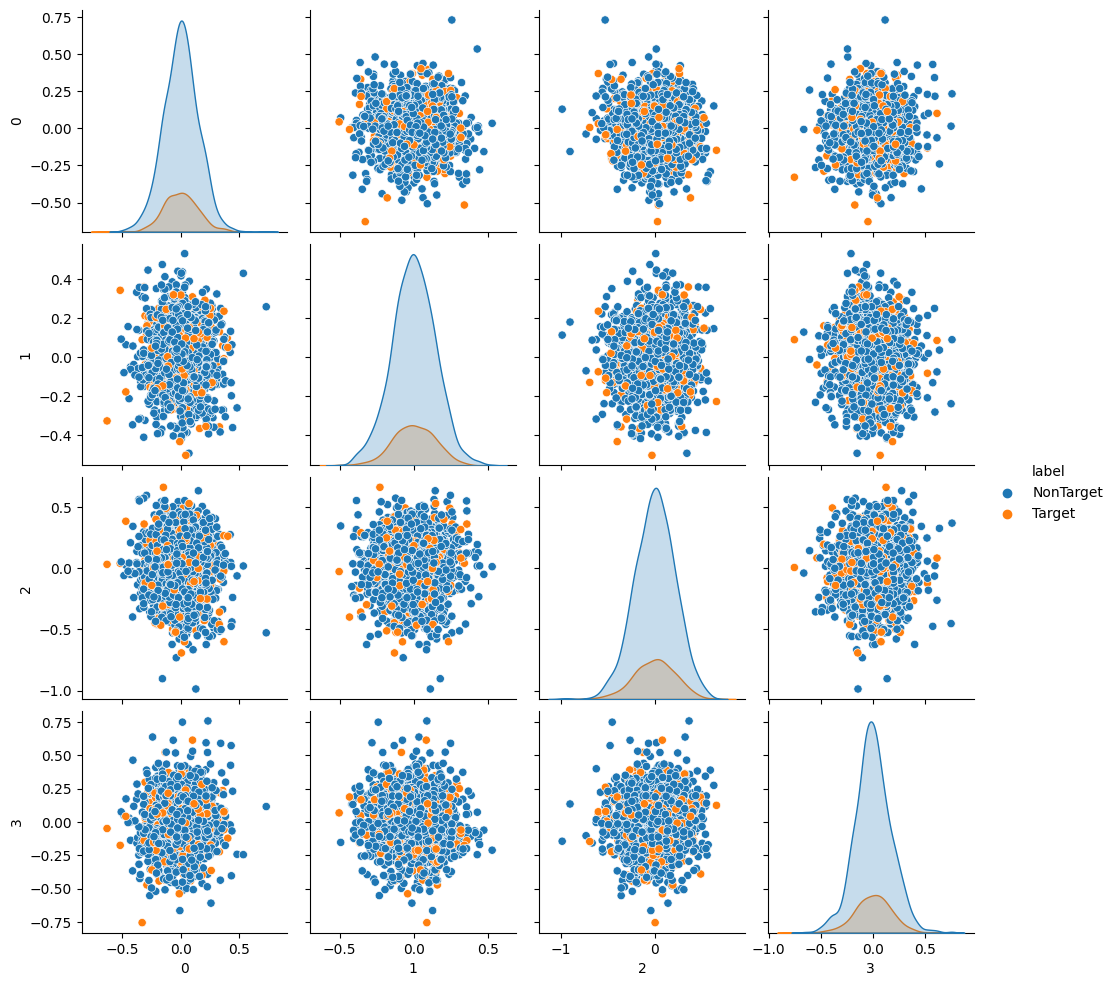

In [61]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')
plt.show()

In [62]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.5132718367346939